# Homework 5. EDA for heart failure dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pink_palette = ['#ffb6c1', '#ff69b4', '#ff1493', '#db7093', '#ffc0cb']
sns.set_palette(pink_palette)

## Upload data, feature types&meanings

In [2]:
df = pd.read_csv('heart.csv')

In [3]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


**Categorical features**: Sex, ChestPainType, FastingBS, RestingECG, ExerciseAngina,ST_Slope, HeartDisease

**Numeric features**: Age, RestingBP, Cholesterol, MaxHR, Oldpeak

- Age: age of the patient [years]

- Sex: sex of the patient [M: Male, F: Female]

- ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]

- RestingBP: resting blood pressure [mm Hg]

- Cholesterol: serum cholesterol [mm/dl]

- FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]

- RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]

- MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]

- ExerciseAngina: exercise-induced angina [Y: Yes, N: No]

- Oldpeak: oldpeak = ST [Numeric value]

- ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]

- HeartDisease: output class [1: heart disease, 0: Normal]

In [4]:
df[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']].describe()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,136.809368,0.887364
std,9.432617,18.514154,109.384145,25.460334,1.066570
min,28.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,173.250000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,138.000000,0.600000
75%,60.000000,140.000000,267.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


## Search for NAs

In [5]:
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

No NAs in df. Great!

## Search for outliers (for numeric features)

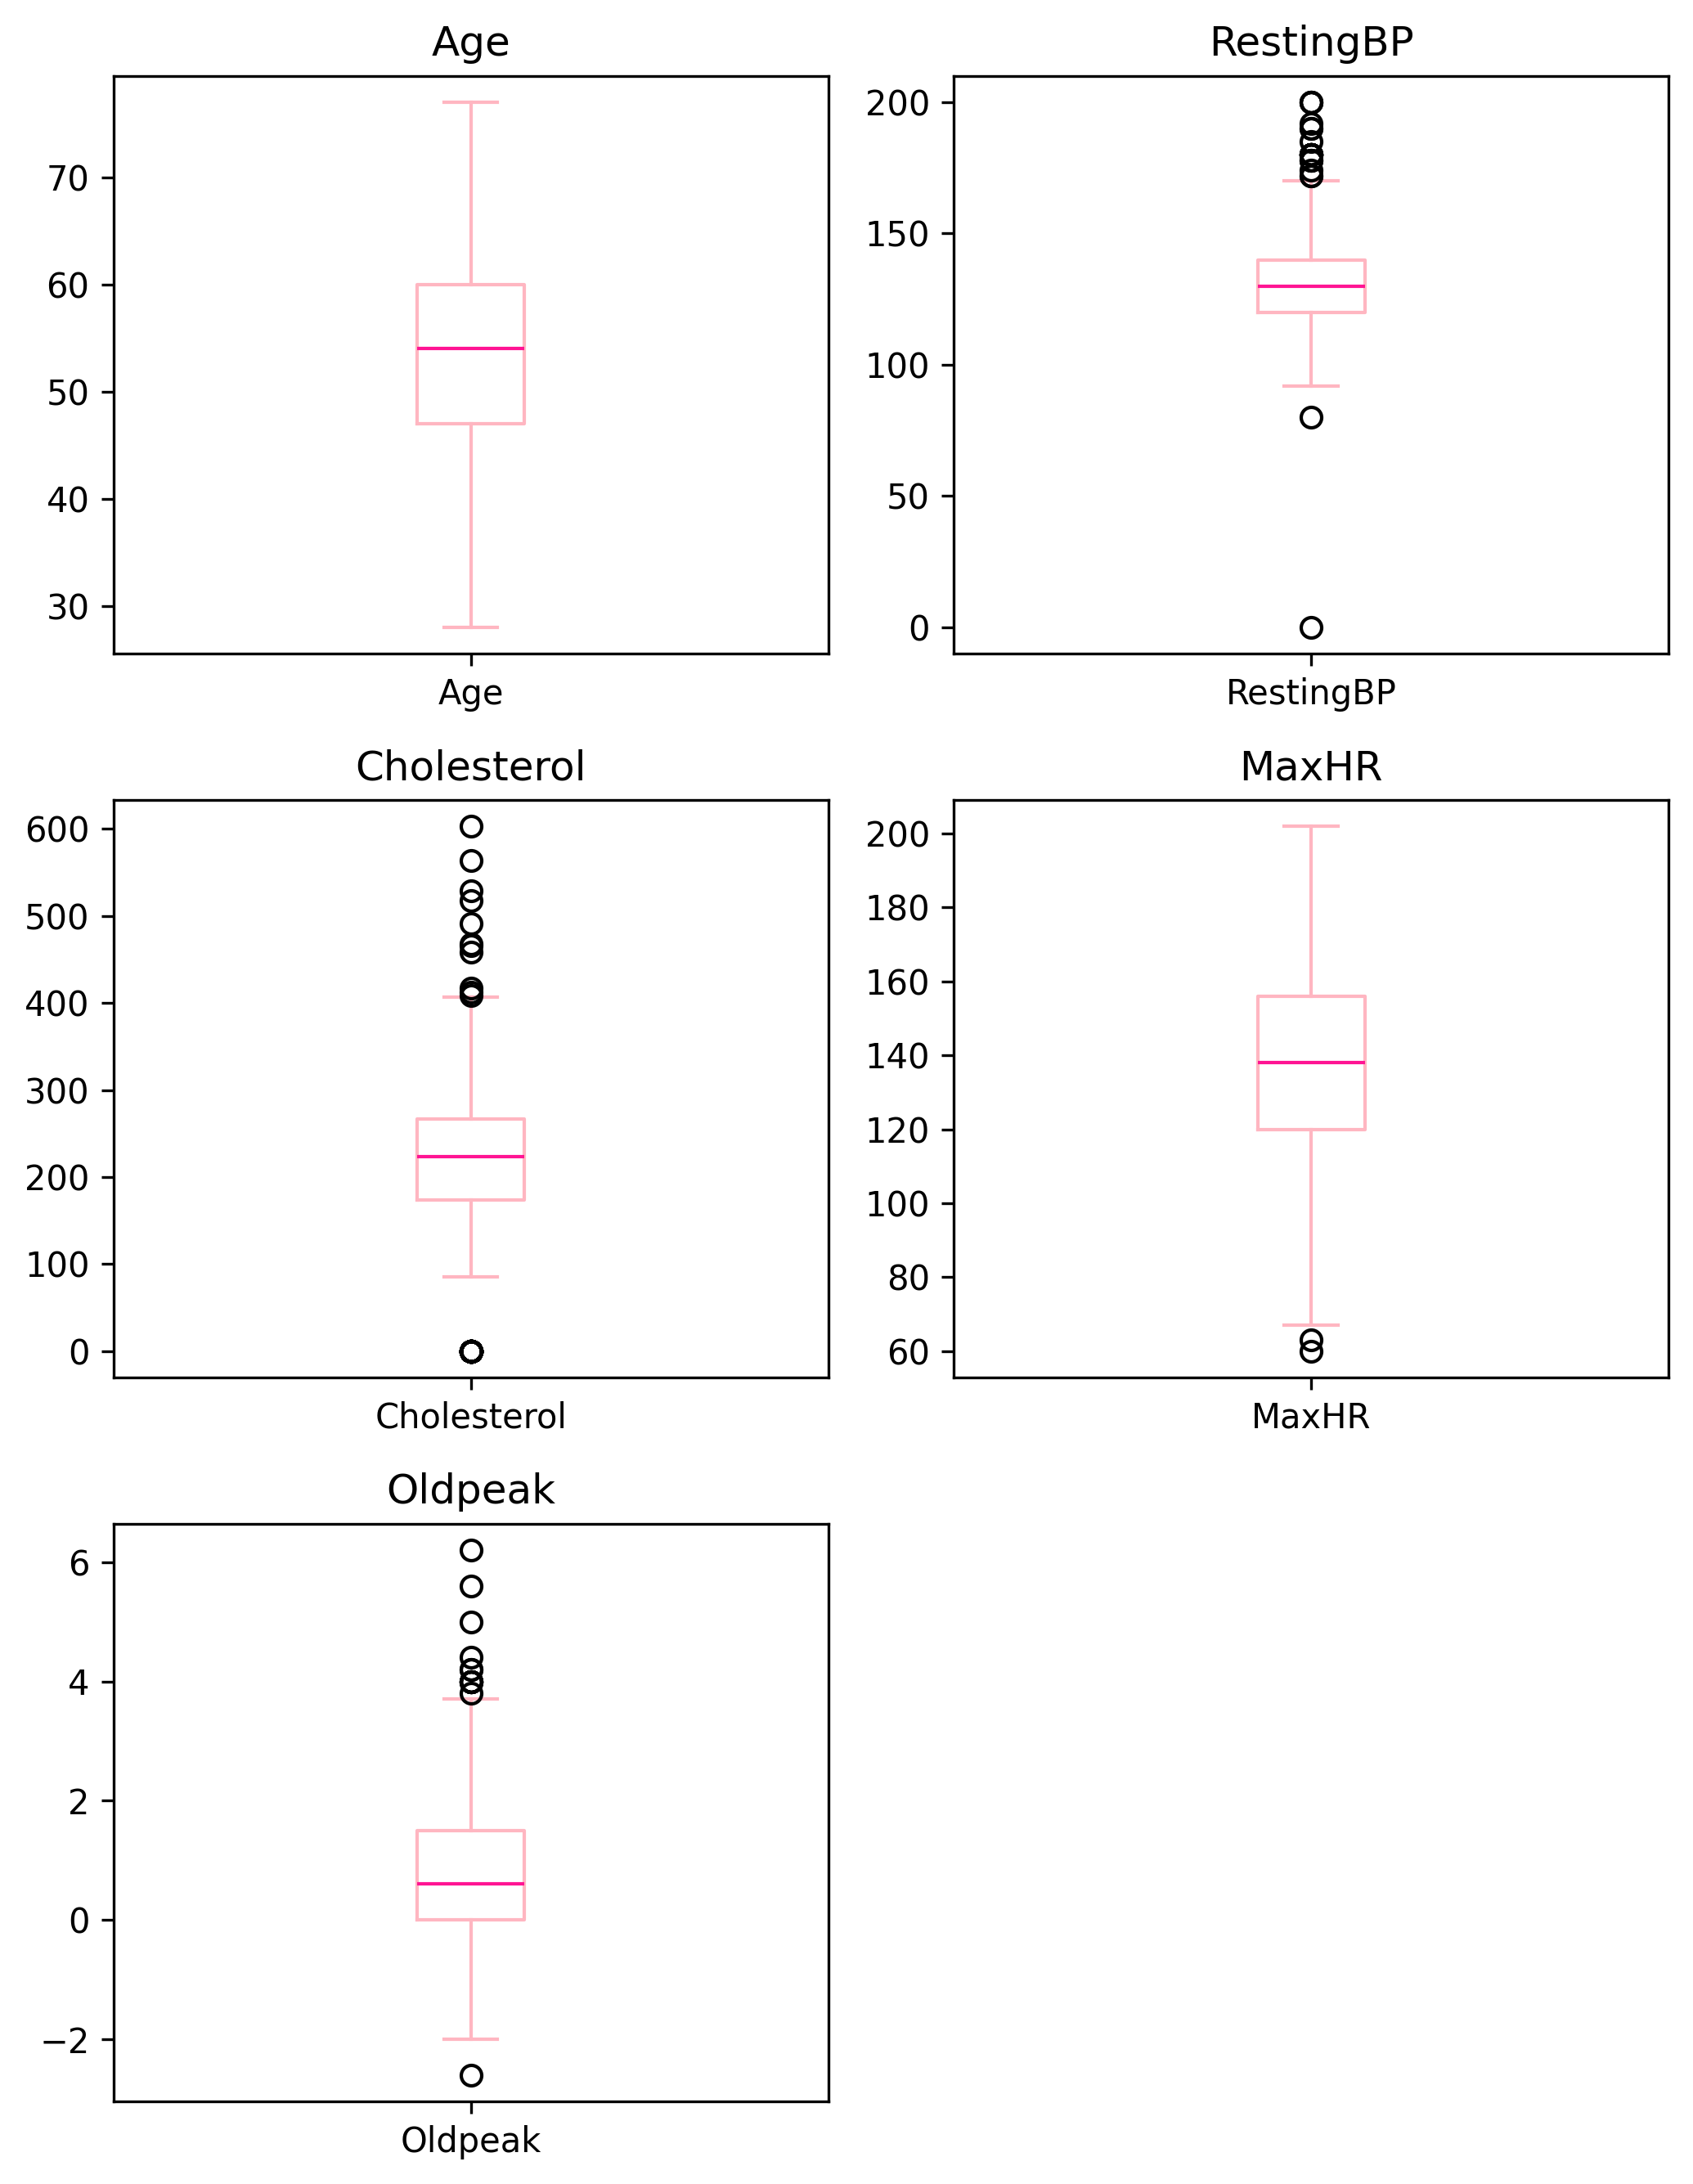

In [6]:
cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(3, 2, figsize=(7, 9), dpi=300)
axes = axes.flatten()

for i, col in enumerate(cols):
    df[col].plot.box(ax=axes[i])
    axes[i].set_title(col, fontsize=12)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

Outliers are present. Since this is *medical data*, it is not recommended to delete or replace it with the average or median

## Distributions

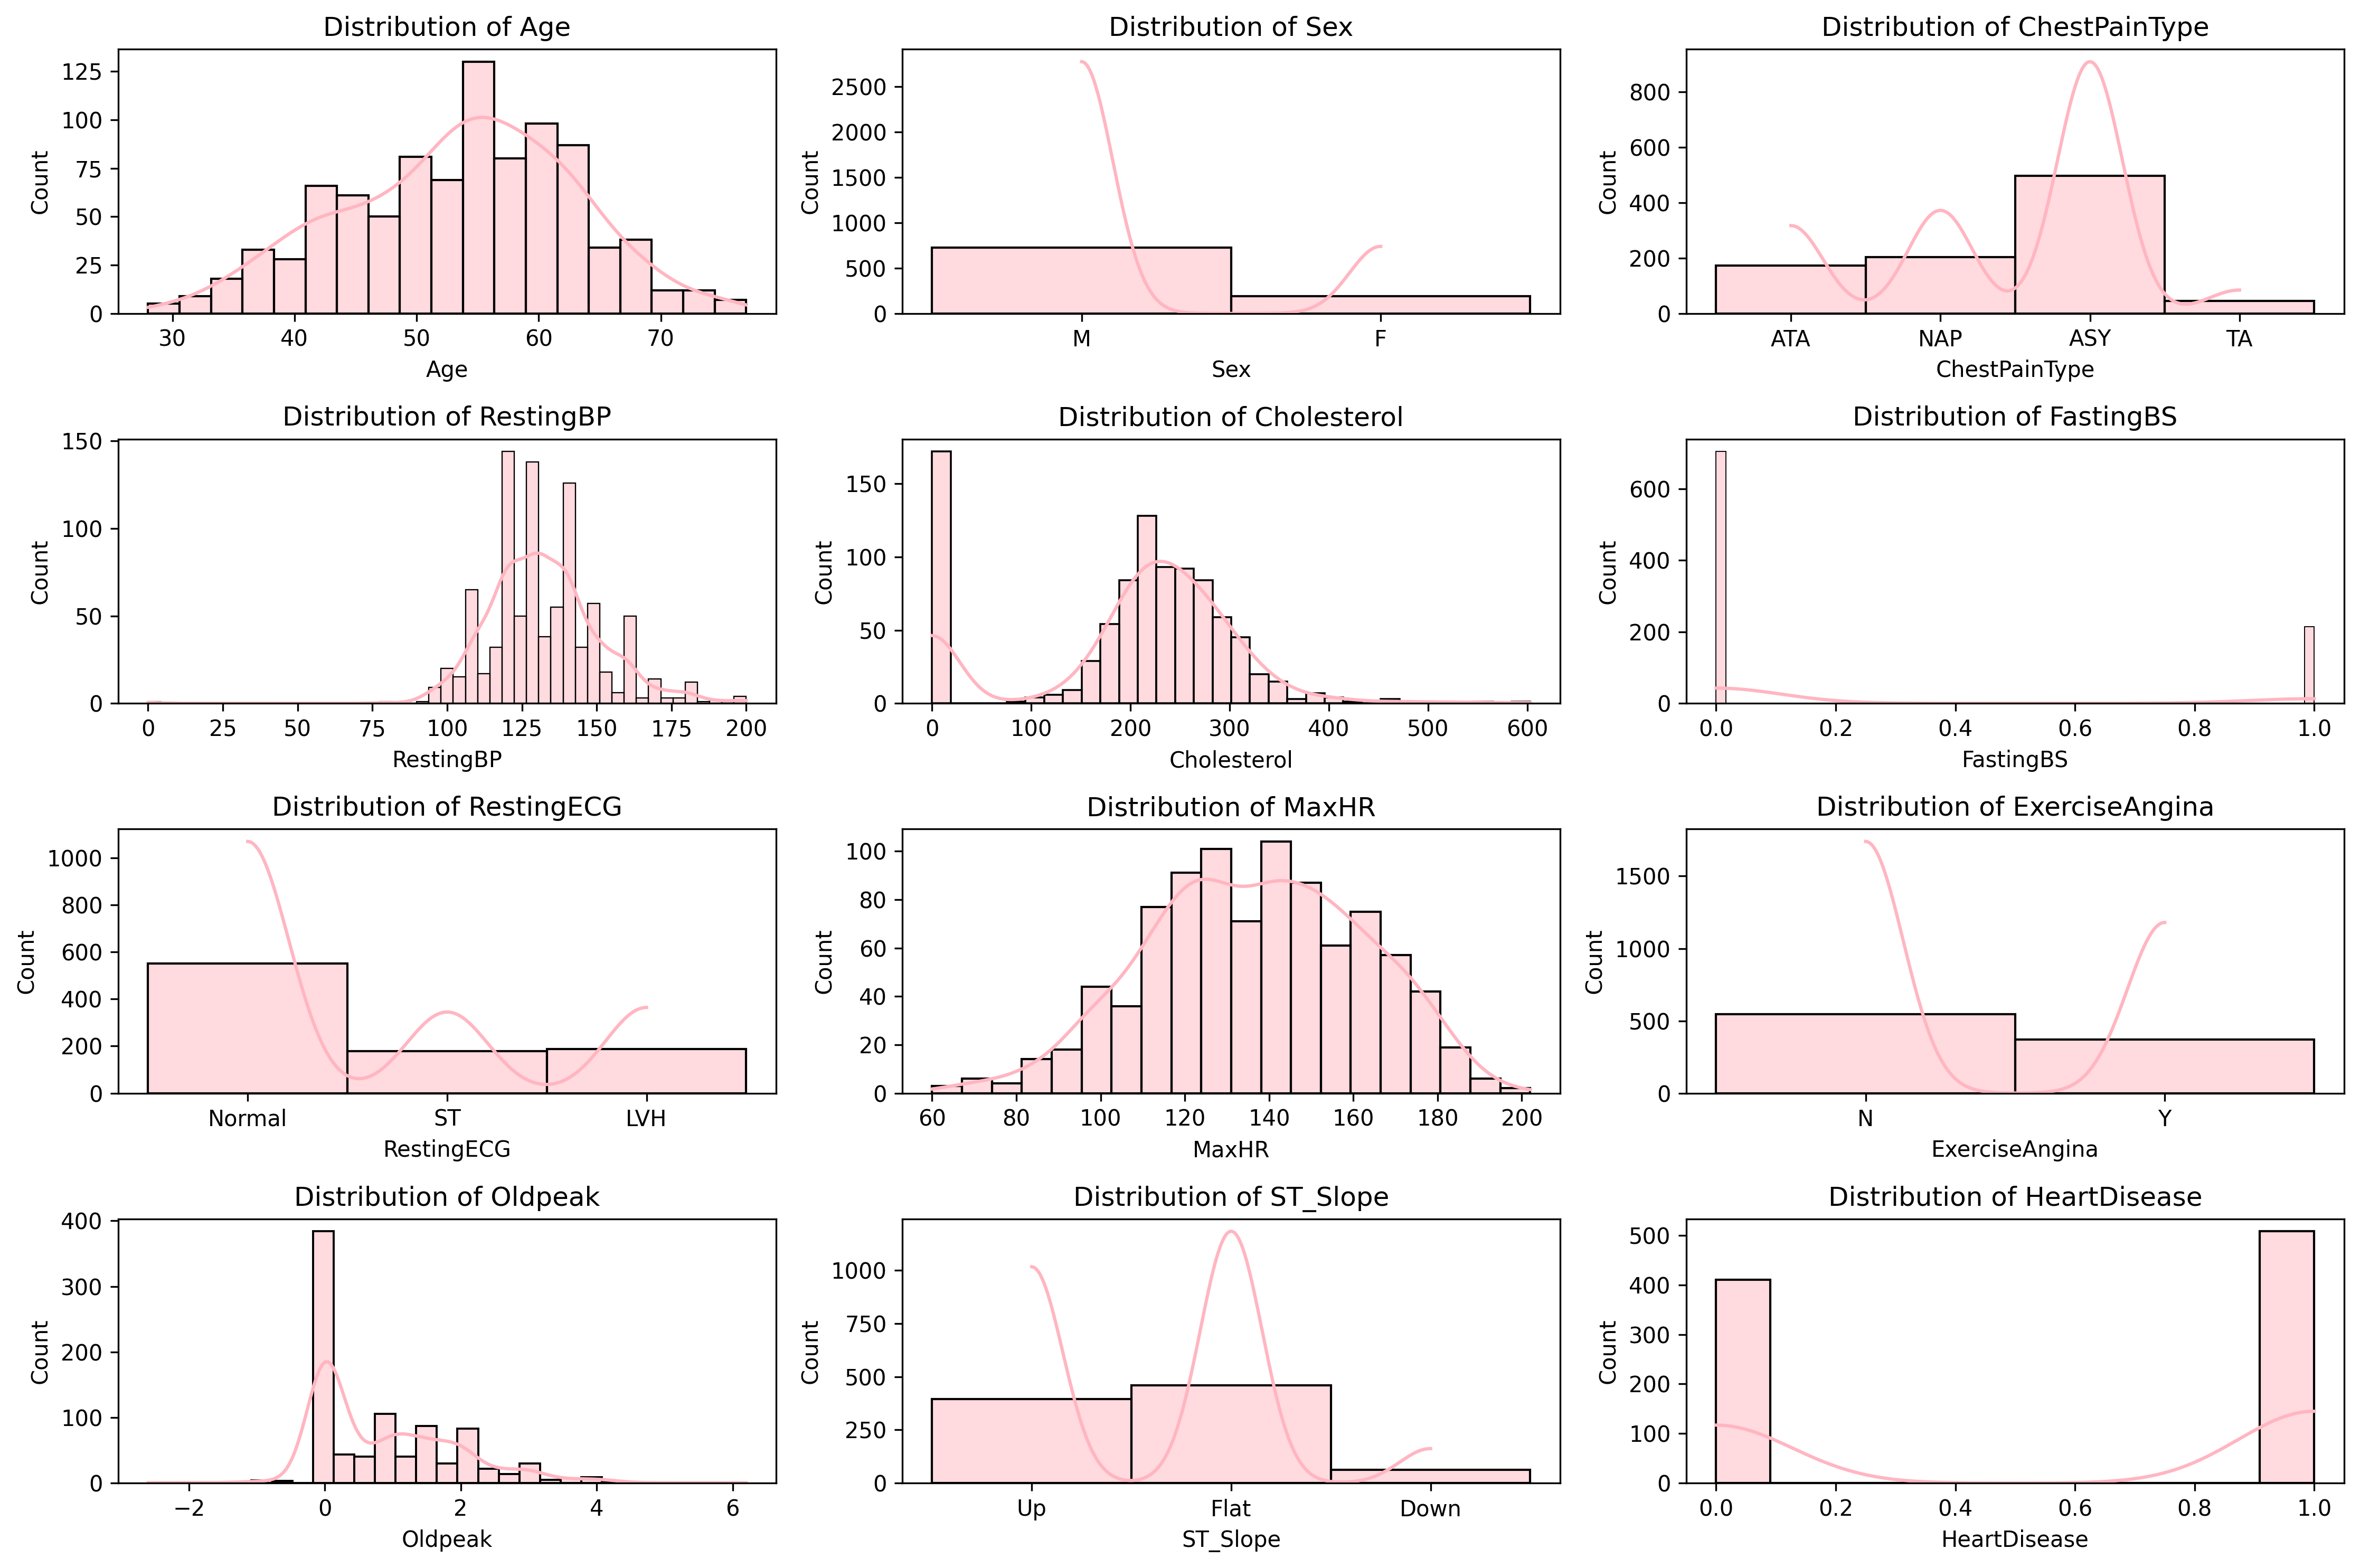

In [7]:
plt.figure(figsize=(15,10), dpi=300)
for i,col in enumerate(df.columns,1):
    plt.subplot(4,3,i)
    plt.title(f'Distribution of {col}')
    sns.histplot(df[col],kde=True)
    plt.tight_layout()
    plt.plot()

- Approximately normal distribution: Age, MaxHR

- Distribution for Cholesterol: too many zero values, may be due error in data registration(?)

## Correlations

<Axes: >

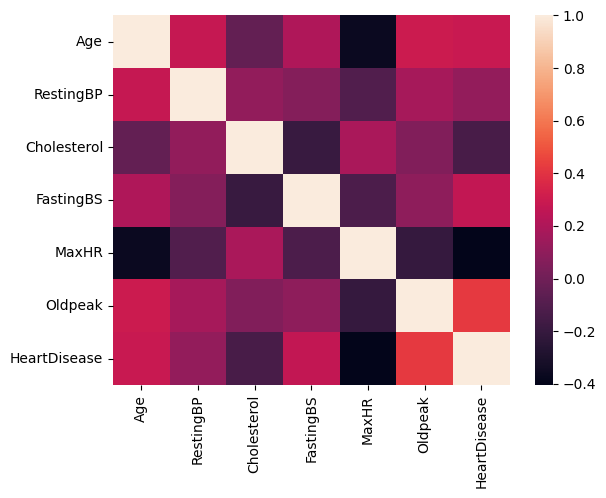

In [8]:
cm = df.corr(method='spearman', numeric_only=True)
sns.heatmap(cm)

In [9]:
df.corr(method='spearman', numeric_only=True)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000000,0.279390,-0.047156,0.201015,-0.365025,0.298250,0.289576
RestingBP,0.279390,1.000000,0.109481,0.066019,-0.107566,0.175313,0.113866
Cholesterol,-0.047156,0.109481,1.000000,-0.192871,0.183900,0.051723,-0.139873
FastingBS,0.201015,0.066019,-0.192871,1.000000,-0.124527,0.098968,0.267291
MaxHR,-0.365025,-0.107566,0.183900,-0.124527,1.000000,-0.205113,-0.404827
Oldpeak,0.298250,0.175313,0.051723,0.098968,-0.205113,1.000000,0.419046
HeartDisease,0.289576,0.113866,-0.139873,0.267291,-0.404827,0.419046,1.000000


Strong correlations:

- Age and MaxHR	(-0.365025)

- HeartDisease MaxHR (-0.404827)	

- HeartDisease and Oldpeak (0.419046)


## Bivariate analysis
This shows the relationship for (n, 2) combination of variable in a DataFrame as a matrix of plots and the diagonal plots are the univariate plots.

[]

<Figure size 4500x3000 with 0 Axes>

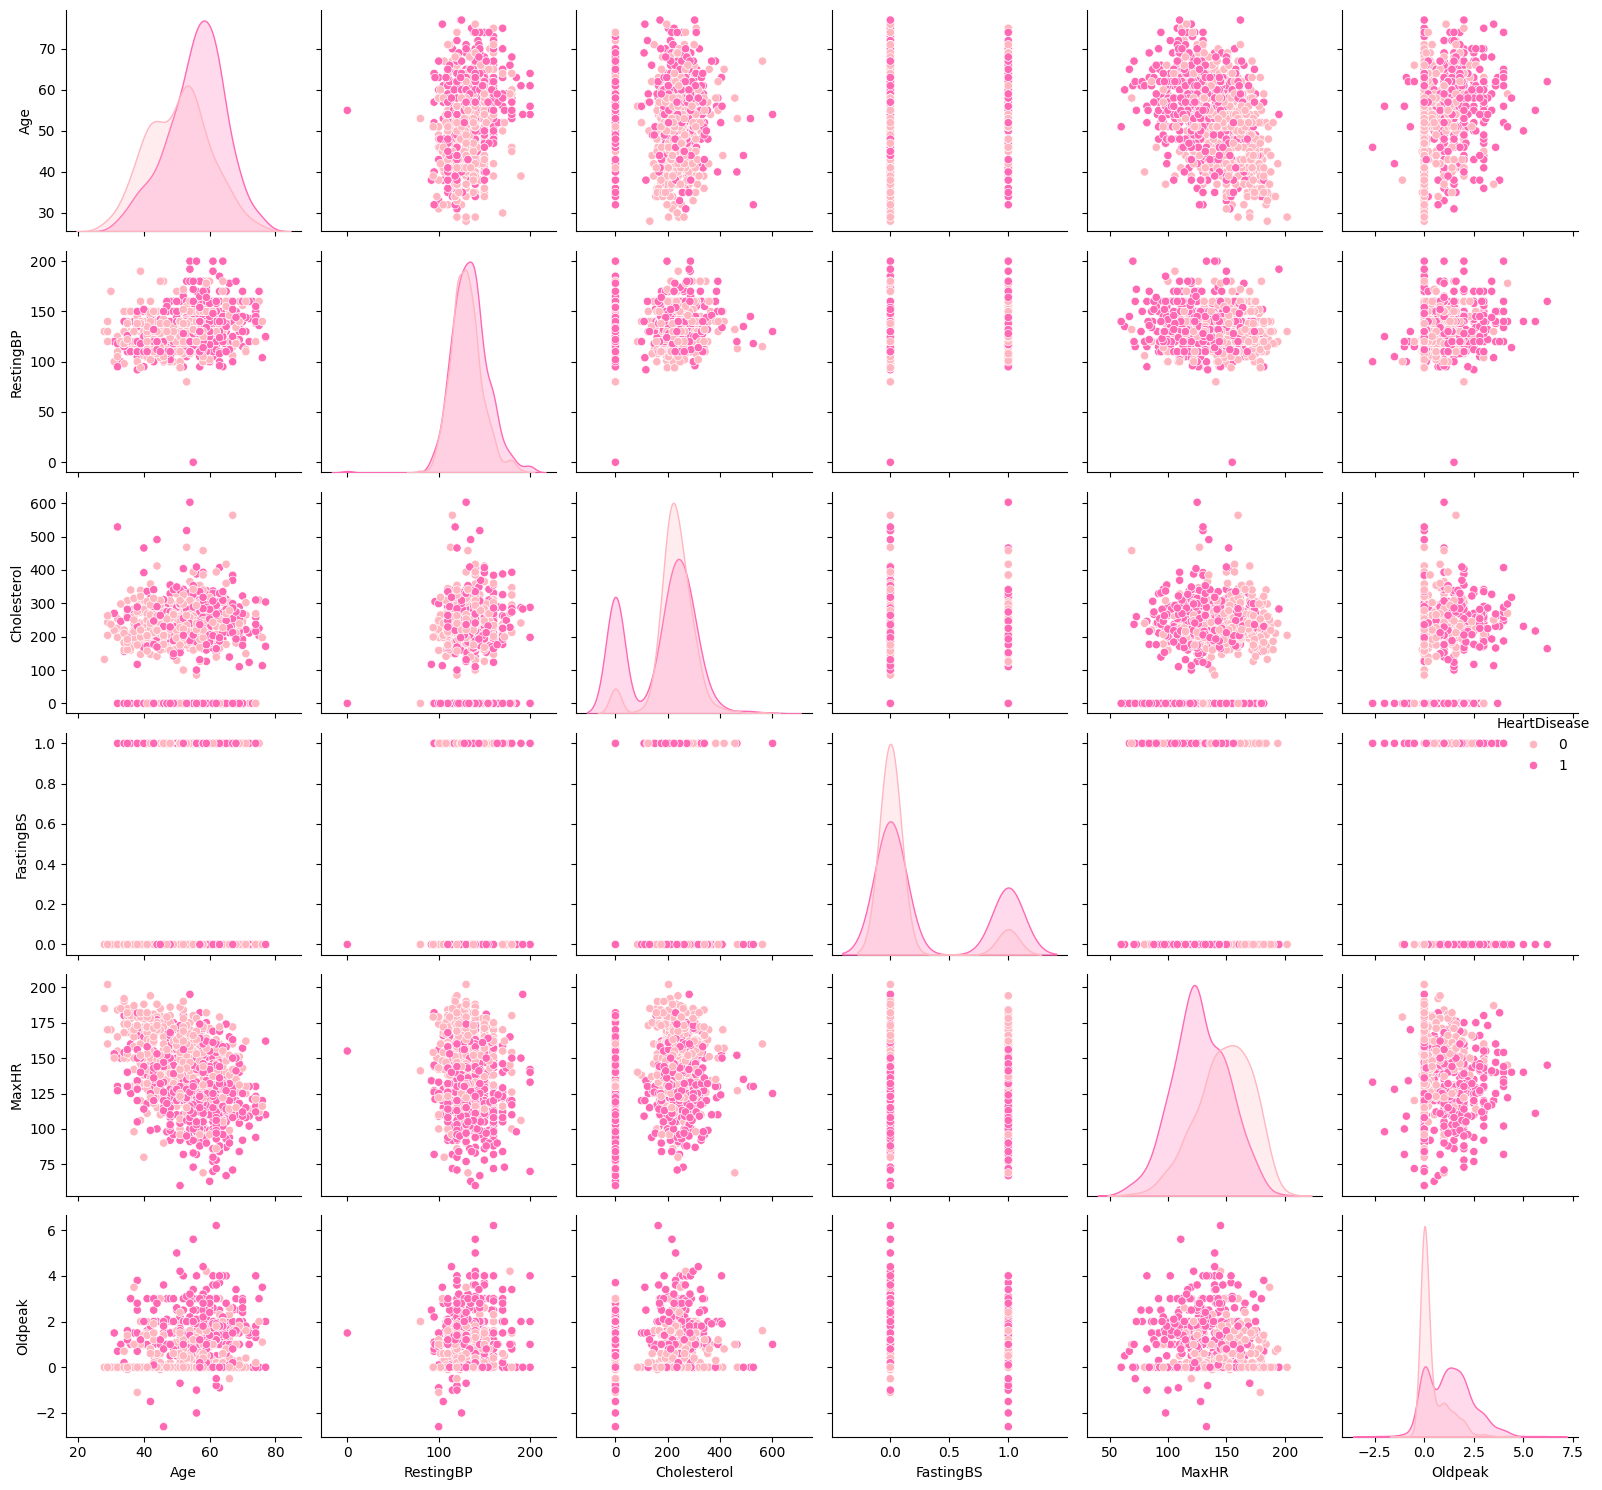

In [10]:
plt.figure(figsize=(15,10), dpi=300)
sns.pairplot(df,hue='HeartDisease', diag_kind='kde')
plt.tight_layout()
plt.plot()

The distribution of metrics for the normal and healthy varies. This can be seen by the different shape of the distributions (Oldpeak, MaxHR), the height of the peak (FastingBS) and its shift (Cholesterol)

## Features effect on target variable (heart failure)

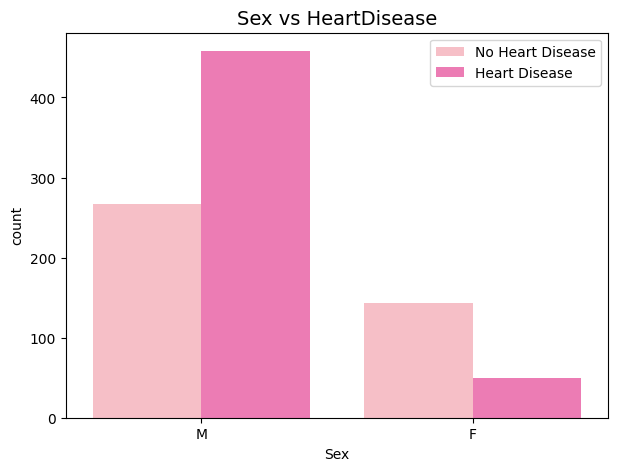

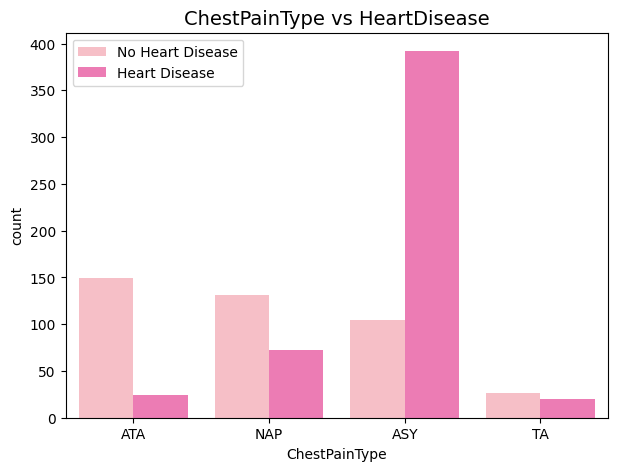

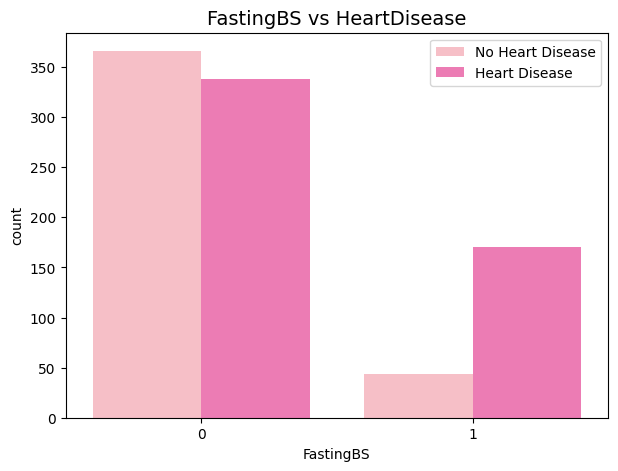

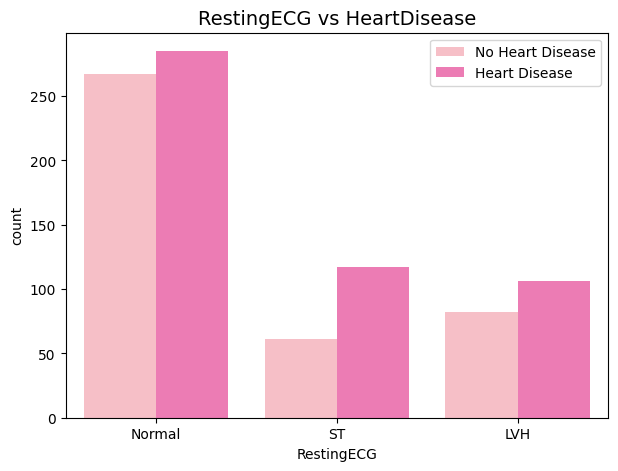

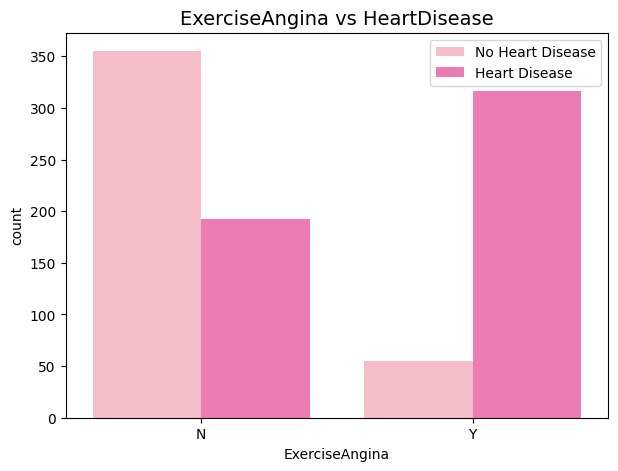

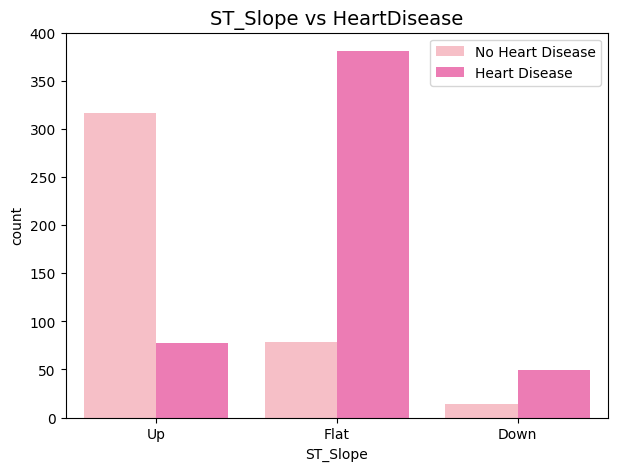

In [11]:
categorical_features = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for feature in categorical_features:
    plt.figure(figsize=(7,5))
    ax = sns.countplot(x=feature, data=df, hue='HeartDisease')
    ax.legend(['No Heart Disease','Heart Disease'])
    ax.set_title(f'{feature} vs HeartDisease', fontsize=14)
    plt.show()

- Heart Disease is more common in men

- The most common chest pain type associated with heart disease is ASY

- Flat ST slope is more common for individuals with heart disease

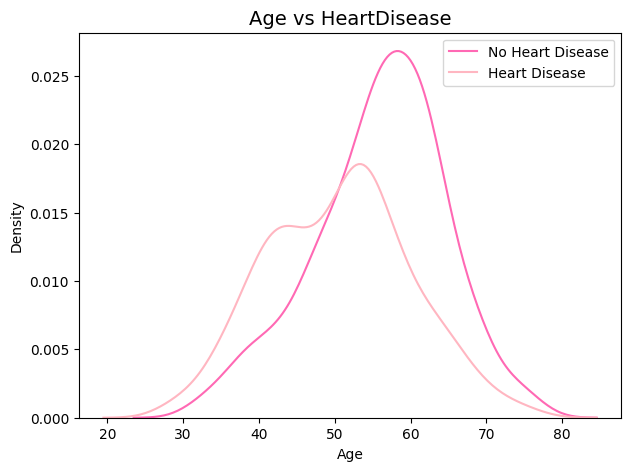

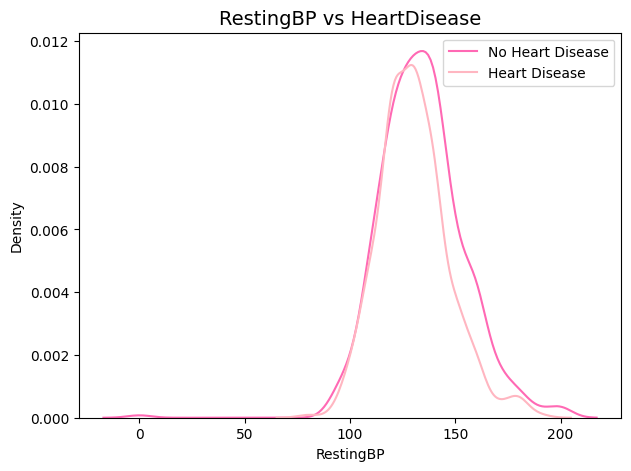

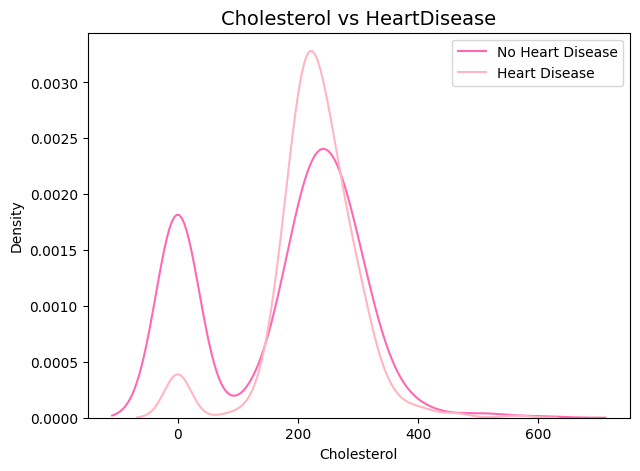

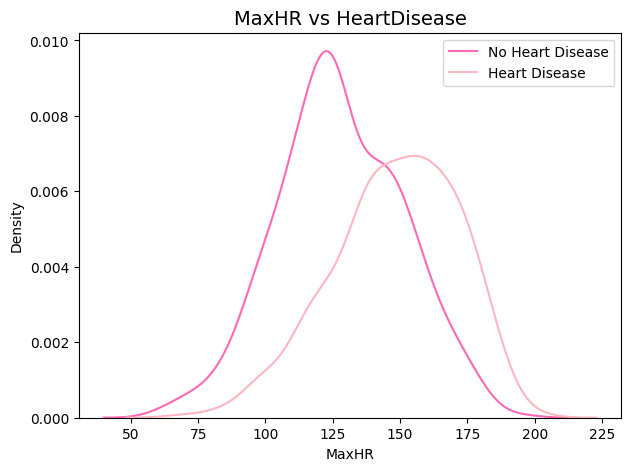

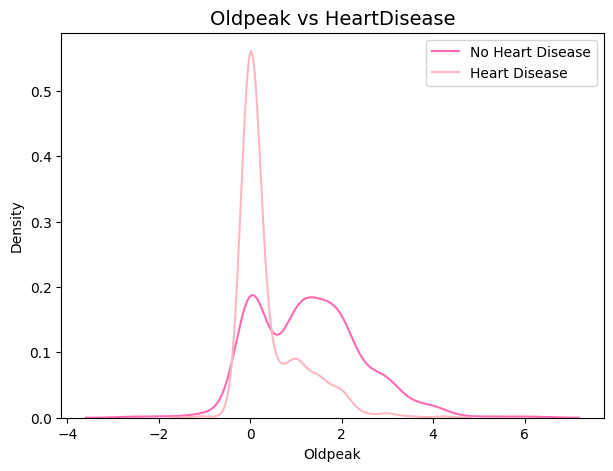

In [12]:
numerical_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
for feature in numerical_features:
    plt.figure(figsize=(7,5))
    ax = sns.kdeplot(x=feature, data=df, hue='HeartDisease')
    ax.legend(['No Heart Disease','Heart Disease'])
    ax.set_title(f'{feature} vs HeartDisease', fontsize=14)
    plt.show()

- MaxHR (heart rate) is higher in patients with heart disease

## Feature engineering

**One-Hot-Encoding**: convert categorical variables into a numerical format. It represents each category as a separate binary column, where a value of 1 indicates the presence of that category and 0 indicates its absence

In [13]:
string_col = df.select_dtypes(include="object").columns
df_1 = pd.get_dummies(df,columns=string_col,drop_first=False)
df_1

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1,False,True,False,...,False,True,False,True,False,True,False,False,True,False
914,68,144,193,1,141,3.4,1,False,True,True,...,False,False,False,True,False,True,False,False,True,False
915,57,130,131,0,115,1.2,1,False,True,True,...,False,False,False,True,False,False,True,False,True,False
916,57,130,236,0,174,0.0,1,True,False,False,...,False,False,True,False,False,True,False,False,True,False


## Conclusion

1. This dataset is greatly balanced and clear: good feature naming, no NAs, a bit of outliers is OK for biomedical data. Features show noticeable differences between patients with and without heart disease

3. It is clear that heart disease mostly correlated with Age, MaxHR and Oldpeak

4. For age 50+, RestingBP between 100 - 175, Cholesterol level of 200 - 300,Max Heart Rate below 160 and positive oldpeak values displays high cases of heart disease. For RestingBP values 100 - 175, highlights too many heart disease patients for all the features.
Cholesterol values 200 - 300 dominates the heart disease cases. Max Heart Rate values below 140 has high probability of being diagnosed with heart diseases